# XGBoost — Model Comparison

This notebook evaluates XGBoost as an alternative classification approach to the Random Forest models.

The model uses the selected features from the previous Random Forest analysis and applies stratified cross-validation with early stopping.

> **Data availability:** The original project datasets are not included in this public repository. Place the processed input files in `../data/` using the filenames referenced below.


## Load and Merge Product and Store Data


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pathlib import Path

DATA_DIR = Path("../data")

df1 = pd.read_excel(DATA_DIR / "products_ML.xlsx")
df2 = pd.read_excel(DATA_DIR / "cleaned_store.xlsx")


In [ ]:
df = pd.merge(df1, df2, on='idstore', how='left')

## Model Development


We used the top features identified as most relevant, excluding Brand 2, to compare XGBoost with the first Random Forest iteration.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

# =========================================================
# STEP 1: Split do Dataset
# =========================================================

train_raw, test_raw = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['sold']
)

print(f"Training rows: {len(train_raw)} | Testing rows: {len(test_raw)}")



# Lista das feature que vamos usar
features = [
    'Margin (%)', 'new_pvp', 'Profit (€)', 'days_until_expiration'
]


# =========================================================
# STEP 2: STRATIFIED 5-FOLD CROSS-VALIDATION
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
best_iterations = []

print("\n" + "="*50)
print("STARTING 5-FOLD CROSS-VALIDATION WITH EARLY STOPPING")
print("="*50)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_raw, train_raw['sold']), 1):
    fold_train_raw = train_raw.iloc[train_idx]
    fold_val_raw = train_raw.iloc[val_idx]

    fold_train_proc = fold_train_raw.copy()
    fold_val_proc = fold_val_raw.copy()


    X_tr, y_tr = fold_train_proc[features], fold_train_proc['sold']
    X_va, y_va = fold_val_proc[features], fold_val_proc['sold']

    xgb_fold = XGBClassifier(
    n_estimators=100,
    learning_rate=0.3,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

    xgb_fold.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    val_proba = xgb_fold.predict_proba(X_va)[:, 1]
    fold_auc = roc_auc_score(y_va, val_proba)
    cv_scores.append(fold_auc)
    best_iterations.append(xgb_fold.best_iteration)

    print(f"Fold {fold} | Best Iteration: {xgb_fold.best_iteration:3d} | Validation ROC-AUC: {fold_auc:.4f}")

mean_cv_auc = np.mean(cv_scores)
optimal_trees = int(np.mean(best_iterations)) + 1

print("\n" + "="*50)
print(f"CV SUMMARY: Mean ROC-AUC = {mean_cv_auc:.4f} (+/- {np.std(cv_scores):.4f})")
print(f"Optimal n_estimators derived from CV = {optimal_trees}")
print("="*50)


# =========================================================
# STEP 4: Treino do Modelo e Teste
# =========================================================
train_processed = train_raw.copy()
test_processed = test_raw.copy()

X_train = train_processed[features]
y_train = train_processed['sold']

X_test = test_processed[features]
y_test = test_processed['sold']

final_xgb_model = XGBClassifier(
    n_estimators=optimal_trees,
    learning_rate=0.3,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

final_xgb_model.fit(X_train, y_train, verbose=False)

# =========================================================
# STEP 5: Avaliacao
# =========================================================
y_pred = final_xgb_model.predict(X_test)
y_proba = final_xgb_model.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT (UNSEEN TEST SET) ===")
print(classification_report(y_test, y_pred))
print(f"Test Set ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")



# ---------------------------------------------------------
# B. PERMUTATION IMPORTANCE (Test Set Evaluation)
# ---------------------------------------------------------
perm_result = permutation_importance(
    final_xgb_model, X_test, y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42
)

perm_importance_df = pd.DataFrame({
    'feature': features,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("\n=== PERMUTATION FEATURE IMPORTANCE (TEST SET ROC-AUC DROP) ===")
print(perm_importance_df.to_string(index=False))

Training rows: 119995 | Testing rows: 29999

STARTING 5-FOLD CROSS-VALIDATION WITH EARLY STOPPING
Fold 1 | Best Iteration:  95 | Validation ROC-AUC: 0.7004
Fold 2 | Best Iteration:  98 | Validation ROC-AUC: 0.7029
Fold 3 | Best Iteration:  80 | Validation ROC-AUC: 0.6998
Fold 4 | Best Iteration:  67 | Validation ROC-AUC: 0.6969
Fold 5 | Best Iteration:  75 | Validation ROC-AUC: 0.6969

CV SUMMARY: Mean ROC-AUC = 0.6994 (+/- 0.0023)
Optimal n_estimators derived from CV = 84

=== CLASSIFICATION REPORT (UNSEEN TEST SET) ===
              precision    recall  f1-score   support

           0       0.63      0.62      0.62     13902
           1       0.68      0.68      0.68     16097

    accuracy                           0.65     29999
   macro avg       0.65      0.65      0.65     29999
weighted avg       0.65      0.65      0.65     29999

Test Set ROC-AUC Score: 0.7037


=== PERMUTATION FEATURE IMPORTANCE (TEST SET ROC-AUC DROP) ===
              feature  importance_mean  importance

In [ ]:
y_train_pred = final_xgb_model.predict(X_train)
y_train_proba = final_xgb_model.predict_proba(X_train)[:, 1]

print("\n=== CLASSIFICATION REPORT (TRAIN SET) ===")
print(classification_report(y_train, y_train_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_train, y_train_proba):.4f}\n")


=== CLASSIFICATION REPORT (TRAIN SET) ===
              precision    recall  f1-score   support

           0       0.63      0.62      0.62     55610
           1       0.68      0.69      0.68     64385

    accuracy                           0.65    119995
   macro avg       0.65      0.65      0.65    119995
weighted avg       0.65      0.65      0.65    119995

ROC-AUC Score: 0.7064



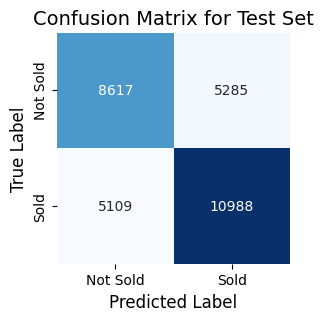

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Sold', 'Sold'], yticklabels=['Not Sold', 'Sold'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Test Set', fontsize=14)
plt.show()

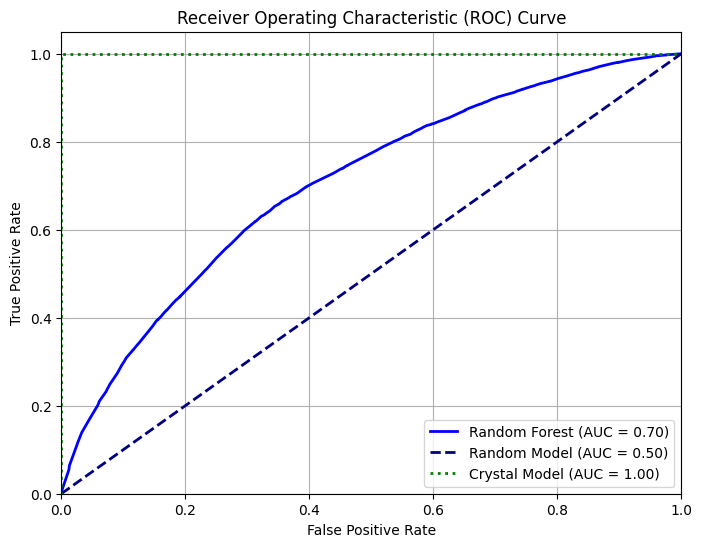

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve for the Random Forest model
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

# Plot the XGBoost ROC curve
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'XGBoost (AUC = {auc_rf:.2f})')

# Plot the random model (diagonal line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Model (AUC = 0.50)')

# Plot the "crystal" (perfect) model
plt.plot([0, 0, 1], [0, 1, 1], color='green', lw=2, linestyle=':', label='Crystal Model (AUC = 1.00)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Conclusion


XGBoost did not achieve better results. Given the additional model complexity without an improvement in performance, we retained the final Random Forest iteration as the selected model.
